In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 250
plt.rcParams['figure.figsize'] = (40,10)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [97]:
df = pd.read_csv('processed_stock_data.csv')
df


,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,283.809289,24643000,259.670586,216.528297,4.369287,279.440002,271.459991,279.775608,2.524879
2007,2019-12-24,284.150718,284.890015,280.977848,283.809289,12119700,260.629372,217.042793,0.000000,283.809289,275.149994,281.012650,1.932721
2008,2019-12-26,284.150718,288.448204,280.977848,283.809289,23280300,261.599157,217.553289,0.000000,283.809289,279.859985,281.576836,2.108589
2009,2019-12-27,284.150718,288.448204,280.977848,283.809289,36566500,262.587943,218.053686,0.000000,283.809289,280.410004,282.062448,2.185120


In [98]:
df.dtypes

Date               object
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
50-day MA         float64
200-day MA        float64
Close_diff        float64
lag_1             float64
lag_7             float64
rolling_mean_7    float64
rolling_std_7     float64
dtype: object

In [99]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [100]:
df.dtypes

Date              datetime64[ns]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
50-day MA                float64
200-day MA               float64
Close_diff               float64
lag_1                    float64
lag_7                    float64
rolling_mean_7           float64
rolling_std_7            float64
dtype: object

In [101]:
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [102]:
df = df[["Date", 'Close']]

In [103]:
df.head()

,Date,Close
0,2012-01-03,58.747143
1,2012-01-04,59.062859
2,2012-01-05,59.718571
3,2012-01-06,60.342857
4,2012-01-09,60.247143


In [104]:
##Creating the t columns that consist of all the date

df["t"] = range(1,len(df) + 1)
df

,Date,Close,t
0,2012-01-03,58.747143,1
1,2012-01-04,59.062859,2
2,2012-01-05,59.718571,3
3,2012-01-06,60.342857,4
4,2012-01-09,60.247143,5
...,...,...,...
2006,2019-12-23,283.809289,2007
2007,2019-12-24,283.809289,2008
2008,2019-12-26,283.809289,2009
2009,2019-12-27,283.809289,2010


In [105]:
## Creating the log columns for the target variable

df["Log_Close"] = np.log(df["Close"])
df

,Date,Close,t,Log_Close
0,2012-01-03,58.747143,1,4.073243
1,2012-01-04,59.062859,2,4.078602
2,2012-01-05,59.718571,3,4.089643
3,2012-01-06,60.342857,4,4.100043
4,2012-01-09,60.247143,5,4.098455
...,...,...,...,...
2006,2019-12-23,283.809289,2007,5.648302
2007,2019-12-24,283.809289,2008,5.648302
2008,2019-12-26,283.809289,2009,5.648302
2009,2019-12-27,283.809289,2010,5.648302


In [106]:
## Creating the square of the t columns

df["t_square"] = (df["t"]**2)
df

,Date,Close,t,Log_Close,t_square
0,2012-01-03,58.747143,1,4.073243,1
1,2012-01-04,59.062859,2,4.078602,4
2,2012-01-05,59.718571,3,4.089643,9
3,2012-01-06,60.342857,4,4.100043,16
4,2012-01-09,60.247143,5,4.098455,25
...,...,...,...,...,...
2006,2019-12-23,283.809289,2007,5.648302,4028049
2007,2019-12-24,283.809289,2008,5.648302,4032064
2008,2019-12-26,283.809289,2009,5.648302,4036081
2009,2019-12-27,283.809289,2010,5.648302,4040100


In [107]:
df.dtypes

Date         datetime64[ns]
Close               float64
t                     int64
Log_Close           float64
t_square              int64
dtype: object

<Axes: >

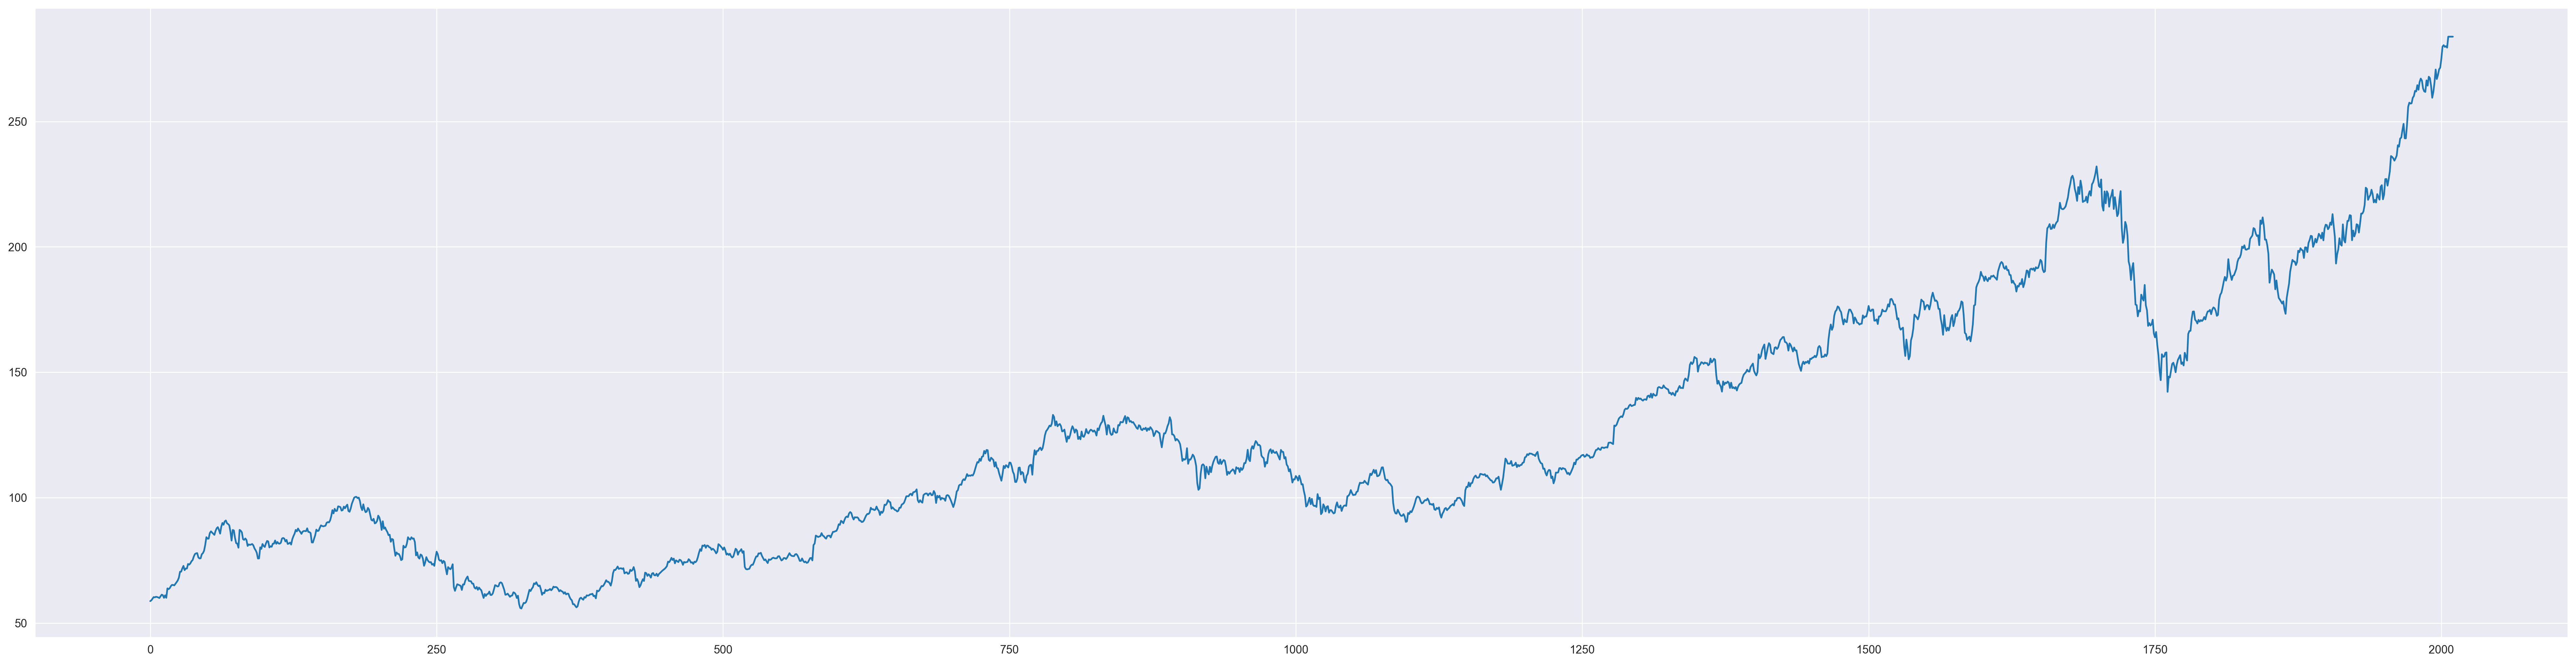

In [108]:
df.Close.plot()

In [109]:
df.shape

(2011, 5)

In [110]:
# Extract month and create 12 binary columns
for i, month in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], start=1):
    df[month] = (df['Date'].dt.month == i).astype(int)

In [112]:
# Set 'Date' as the index
df.set_index('Date', inplace=True)

In [113]:
df

,Close,t,Log_Close,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Date,,,,,,,,,,,,,,,,
2012-01-03,58.747143,1,4.073243,1,1,0,0,0,0,0,0,0,0,0,0,0
2012-01-04,59.062859,2,4.078602,4,1,0,0,0,0,0,0,0,0,0,0,0
2012-01-05,59.718571,3,4.089643,9,1,0,0,0,0,0,0,0,0,0,0,0
2012-01-06,60.342857,4,4.100043,16,1,0,0,0,0,0,0,0,0,0,0,0
2012-01-09,60.247143,5,4.098455,25,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,283.809289,2007,5.648302,4028049,0,0,0,0,0,0,0,0,0,0,0,1
2019-12-24,283.809289,2008,5.648302,4032064,0,0,0,0,0,0,0,0,0,0,0,1
2019-12-26,283.809289,2009,5.648302,4036081,0,0,0,0,0,0,0,0,0,0,0,1


In [114]:
# Splitting data
Train = df.head(1981)
Test = df.tail(30)

In [115]:
Test

,Close,t,Log_Close,t_square,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Date,,,,,,,,,,,,,,,,
2019-11-15,265.760010,1982,5.582594,3928324,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-18,267.100006,1983,5.587623,3932289,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-19,266.290009,1984,5.584586,3936256,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-20,263.190002,1985,5.572876,3940225,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-21,262.010010,1986,5.568383,3944196,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-22,261.779999,1987,5.567504,3948169,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-25,266.369995,1988,5.584886,3952144,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-26,264.290009,1989,5.577047,3956121,0,0,0,0,0,0,0,0,0,0,1,0
2019-11-27,267.839996,1990,5.590390,3960100,0,0,0,0,0,0,0,0,0,0,1,0


In [116]:
from sklearn.metrics import mean_squared_error

In [118]:
#Linear Model
import statsmodels.formula.api as smf 

linear_model = smf.ols('Close~t',data=Train).fit()
pred_linear =  pd.Series(linear_model.predict(pd.DataFrame(Test['t'])))
rmse_linear = np.sqrt(mean_squared_error(Test['Close'], pred_linear))
rmse_linear

71.2500532963424

In [119]:
#Exponential

Exp = smf.ols('Log_Close~t',data=Train).fit()
pred_Exp = pd.Series(Exp.predict(pd.DataFrame(Test['t'])))
rmse_Exp = np.sqrt(mean_squared_error(Test['Close'], pred_Exp))
rmse_Exp

266.2504671350161

In [120]:
#Quadratic 

Quad = smf.ols('Close~t+t_square',data=Train).fit()
pred_Quad = pd.Series(Quad.predict(Test[["t","t_square"]]))
rmse_Quad = np.sqrt(mean_squared_error(Test['Close'],pred_Quad))
rmse_Quad

44.791750857721624

In [121]:
#Additive seasonality 
add_sea = smf.ols('Close~Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=Train).fit()
pred_add_sea = pd.Series(add_sea.predict(Test[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']]))
rmse_add_sea = np.sqrt(mean_squared_error(Test['Close'], pred_add_sea))
rmse_add_sea

149.3658688290189

In [122]:
#Additive Seasonality Quadratic 

add_sea_Quad = smf.ols('Close~t+t_square+Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data=Train).fit()
pred_add_sea_quad = pd.Series(add_sea_Quad.predict(Test[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','t','t_square']]))
rmse_add_sea_quad = np.sqrt(mean_squared_error(Test['Close'], pred_add_sea_quad))
rmse_add_sea_quad

46.48384396512597

In [124]:
#Multiplicative Seasonality 

Mul_Add_sea = smf.ols('Log_Close~t+Jan+Feb+Mar+Apr+May+Jun+Jul+Aug+Sep+Oct+Nov',data = Train).fit()
pred_Mult_add_sea = pd.Series(Mul_Add_sea.predict(Test))
rmse_Mult_add_sea = np.sqrt(mean_squared_error(Test['Close'], pred_Mult_add_sea))
rmse_Mult_add_sea 

266.2614052056088

In [125]:
#Compare the results 

data = {"MODEL":pd.Series(["rmse_linear","rmse_Exp","rmse_Quad","rmse_add_sea","rmse_add_sea_quad","rmse_Mult_sea"]),"RMSE_Values":pd.Series([rmse_linear,rmse_Exp,rmse_Quad,rmse_add_sea,rmse_add_sea_quad,rmse_Mult_add_sea])}
table_rmse = pd.DataFrame(data)
table_rmse.sort_values(['RMSE_Values'])

,MODEL,RMSE_Values
2,rmse_Quad,44.791751
4,rmse_add_sea_quad,46.483844
0,rmse_linear,71.250053
3,rmse_add_sea,149.365869
1,rmse_Exp,266.250467
5,rmse_Mult_sea,266.261405


In [127]:
pred_Quad

Date
2019-11-15    225.005517
2019-11-18    225.158297
2019-11-19    225.311155
2019-11-20    225.464091
2019-11-21    225.617105
2019-11-22    225.770196
2019-11-25    225.923365
2019-11-26    226.076612
2019-11-27    226.229937
2019-11-29    226.383339
2019-12-02    226.536820
2019-12-03    226.690377
2019-12-04    226.844013
2019-12-05    226.997727
2019-12-06    227.151518
2019-12-09    227.305387
2019-12-10    227.459334
2019-12-11    227.613358
2019-12-12    227.767460
2019-12-13    227.921640
2019-12-16    228.075898
2019-12-17    228.230234
2019-12-18    228.384647
2019-12-19    228.539138
2019-12-20    228.693707
2019-12-23    228.848354
2019-12-24    229.003078
2019-12-26    229.157880
2019-12-27    229.312760
2019-12-30    229.467718
dtype: float64